In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt

In [3]:
# grab all daily files and combine
files = glob.glob("POWER_*.csv")

dfs = [pd.read_csv(f) for f in files]
wide = pd.concat(dfs, ignore_index=True)

In [5]:
# pivot wide -> long
id_cols = ["entity_id", "type", "unit"]
long = wide.melt(id_vars=id_cols, var_name="timestamp", value_name="power_w")
long = long.dropna(subset=["power_w"])

long["power_w"] = pd.to_numeric(long["power_w"])
long["timestamp"] = pd.to_datetime(long["timestamp"], format="mixed", utc=True)
long["timestamp_perth"] = long["timestamp"].dt.tz_convert("Australia/Perth")

long = long.sort_values("timestamp").drop_duplicates(subset="timestamp")

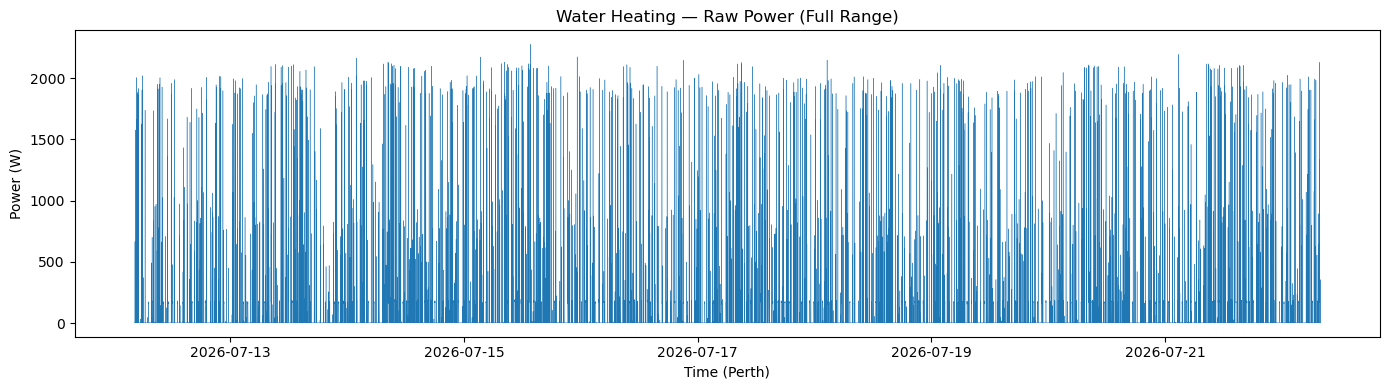

In [6]:
# full range plot
plt.figure(figsize=(14, 4))
plt.plot(long["timestamp_perth"], long["power_w"], linewidth=0.3)
plt.title("Water Heating — Raw Power (Full Range)")
plt.xlabel("Time (Perth)")
plt.ylabel("Power (W)")
plt.tight_layout()
plt.show()

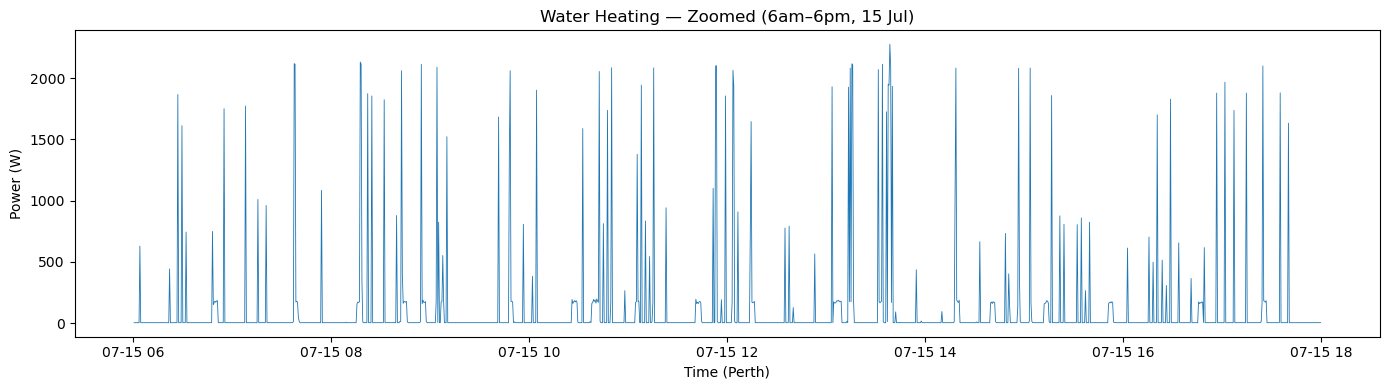

In [20]:
zoom = long[
    (long["timestamp_perth"] >= "2026-07-15 06:00:00+08:00") &
    (long["timestamp_perth"] <= "2026-07-15 18:00:00+08:00")
]

plt.figure(figsize=(14, 4))
plt.plot(zoom["timestamp_perth"], zoom["power_w"], linewidth=0.6)
plt.title("Water Heating — Zoomed (6am–6pm, 15 Jul)")
plt.xlabel("Time (Perth)")
plt.ylabel("Power (W)")
plt.tight_layout()
plt.show()

In [12]:
spike_candidates = long[long["power_w"] > 500].sort_values("timestamp_perth")
print(spike_candidates[["timestamp_perth", "power_w"]].head(20))

                        timestamp_perth   power_w
252975 2026-07-12 04:23:22.520747+08:00   665.456
253140 2026-07-12 04:30:52.509769+08:00  1576.548
253305 2026-07-12 04:38:22.530004+08:00  2004.601
253360 2026-07-12 04:40:52.529402+08:00  1665.388
253646 2026-07-12 04:53:52.524045+08:00  1884.151
253756 2026-07-12 04:58:52.531796+08:00  1868.083
253811 2026-07-12 05:01:22.522917+08:00  1609.487
253921 2026-07-12 05:06:22.504003+08:00  1915.577
254823 2026-07-12 05:47:23.505838+08:00  1625.853
254878 2026-07-12 05:49:53.515688+08:00  1903.253
254988 2026-07-12 05:54:53.537701+08:00  2019.535
255714 2026-07-12 06:27:54.506110+08:00  1737.649
257617 2026-07-12 07:54:25.524560+08:00   700.906
126515 2026-07-12 08:12:25.522552+08:00   837.162
126570 2026-07-12 08:14:55.519368+08:00  1734.137
126900 2026-07-12 08:29:56.048176+08:00   953.644
127186 2026-07-12 08:42:56.517887+08:00   970.502
127472 2026-07-12 08:55:57.525617+08:00   591.355
127527 2026-07-12 08:58:27.511613+08:00  1950.342


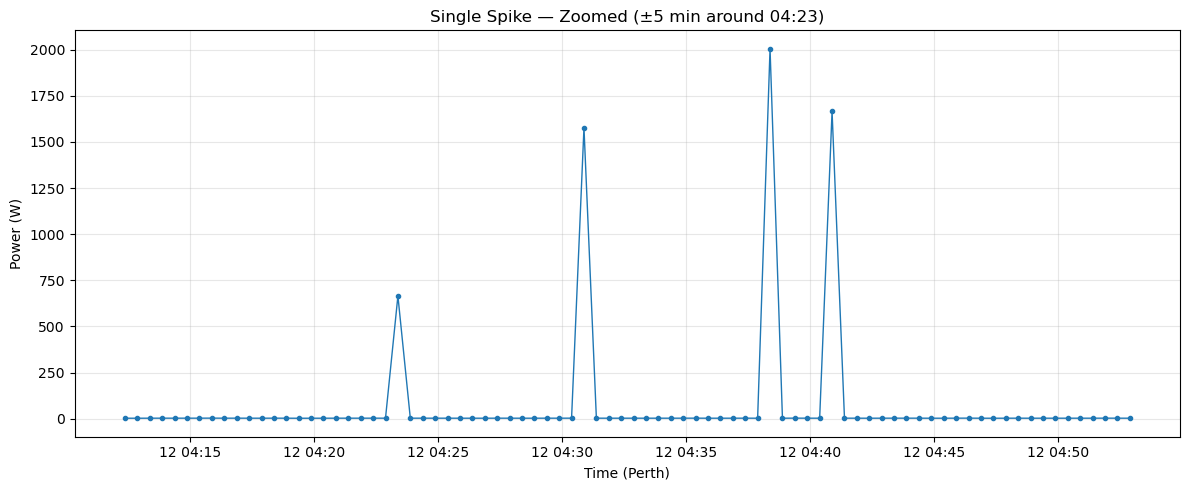

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

anchor = pd.Timestamp("2026-07-12 04:23:22.520747+08:00", tz="Australia/Perth")  # replace with a real spike time from above
window = long[
    (long["timestamp_perth"] >= anchor - pd.Timedelta(minutes=30)) &
    (long["timestamp_perth"] <= anchor + pd.Timedelta(minutes=30))
]

plt.figure(figsize=(12, 5))
plt.plot(window["timestamp_perth"], window["power_w"], marker="o", markersize=3, linewidth=1)
plt.title(f"Single Spike — Zoomed (±5 min around {anchor.strftime('%H:%M')})")
plt.xlabel("Time (Perth)")
plt.ylabel("Power (W)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

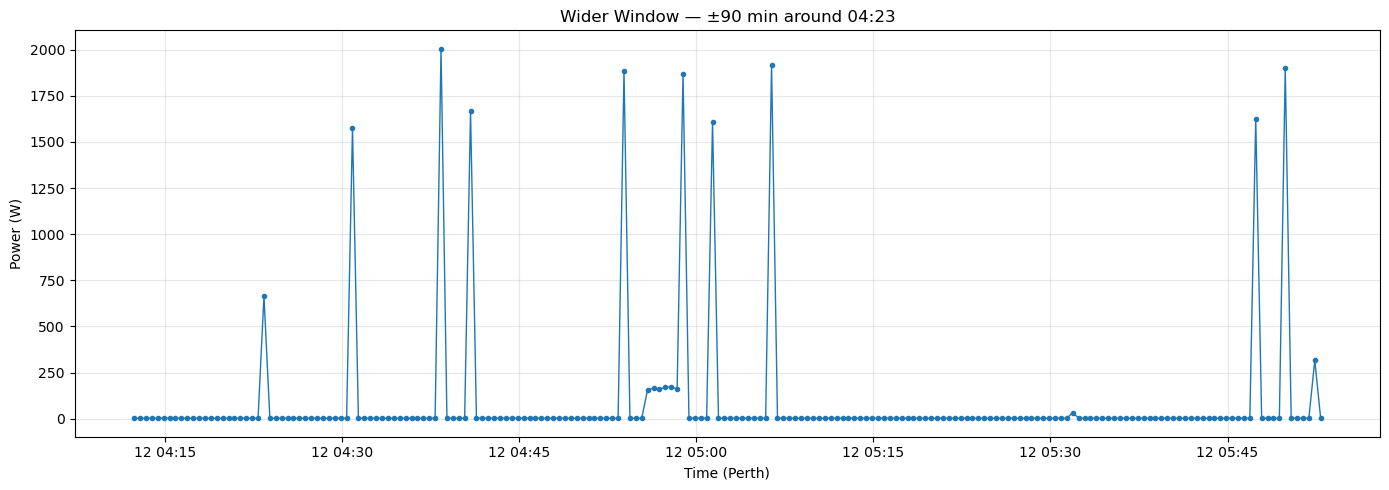

In [18]:
window_wide = long[
    (long["timestamp_perth"] >= anchor - pd.Timedelta(minutes=90)) &
    (long["timestamp_perth"] <= anchor + pd.Timedelta(minutes=90))
]

plt.figure(figsize=(14, 5))
plt.plot(window_wide["timestamp_perth"], window_wide["power_w"], marker="o", markersize=3, linewidth=1)
plt.title(f"Wider Window — ±90 min around {anchor.strftime('%H:%M')}")
plt.xlabel("Time (Perth)")
plt.ylabel("Power (W)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# seems like old mechanical thermostats cycling on legacy hysteresis bands
# outdated, wasteful water heating system that turns itself on and off strictly based on temperature drops, regardless of whether anyone actually needs hot water at that moment.